# **NLP-Based Sentiment Analysis of YouTube Comments Using Machine Learning**

This project uses Natural Language Processing and Machine Learning
to classify YouTube comments into Positive, Neutral, and Negative sentiments.

**Import Required Libraries**

**Description:**
This section imports Python libraries required for data processing, visualization, NLP preprocessing, TF-IDF feature extraction, machine learning, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


**Download NLTK Resources**

**Description:**
NLTK resources are required for English stopword removal and lemmatization during text preprocessing.



In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK resources downloaded successfully!


**Load the Dataset**

**Description:**
This section loads the YouTube comments dataset into Google Colab using the Pandas library and displays the dataset structure and initial records.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/YoutubeCommentsDataSet.csv')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (18408, 2)


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['Comment', 'Sentiment']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


**Check Missing Values**

**Description:**
Missing values are checked before preprocessing the dataset.

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Comment      44
Sentiment     0
dtype: int64


**Select Required Columns**

**Description:**
Only the comment and sentiment columns are required for this project.

In [ ]:
df = df[['Comment', 'Sentiment']].copy()

df.columns = ['comment', 'sentiment']

**Remove Missing Values**

**Description:**
Rows containing missing comments or sentiment labels are removed.

In [ ]:
df = df.dropna(
    subset=['comment', 'sentiment']
)

print("Dataset Shape After Removing Missing Values:")
print(df.shape)

Dataset Shape After Removing Missing Values:
(18364, 2)


In [ ]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(17874, 2)


**Check Sentiment Classes**

**Description:**
This section displays the sentiment categories available in the dataset.

In [ ]:
print("Sentiment Classes:")

print(
    df['sentiment'].unique()
)

Sentiment Classes:
['neutral' 'negative' 'positive']


**Standardize Sentiment Labels**

**Description:**
The labels are converted into a consistent format so that the model can process them correctly.

In [ ]:
df['sentiment'] = (
    df['sentiment']
    .astype(str)
    .str.strip()
    .str.capitalize()
)

print(
    df['sentiment'].value_counts()
)

sentiment
Positive    11054
Neutral      4503
Negative     2317
Name: count, dtype: int64


**Keep Required Sentiment Classes**

**Description:**

Only Positive, Neutral, and Negative comments are used in this project.

In [ ]:
valid_sentiments = [
    'Positive',
    'Neutral',
    'Negative'
]

df = df[
    df['sentiment'].isin(valid_sentiments)
].copy()

print("Final Sentiment Classes:")
print(df['sentiment'].unique())

print("\nFinal Sentiment Distribution:")
print(df['sentiment'].value_counts())

Final Sentiment Classes:
['Neutral' 'Negative' 'Positive']

Final Sentiment Distribution:
sentiment
Positive    11054
Neutral      4503
Negative     2317
Name: count, dtype: int64


**Visualize Sentiment Distribution**

**Description:**
A bar chart is used to show the number of comments belonging to each sentiment category.

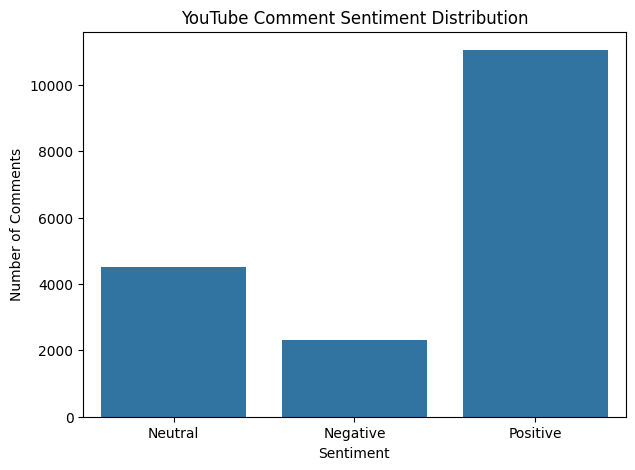

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='sentiment'
)

plt.title("YouTube Comment Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()

**Set Up Text Preprocessing**

**Description:**
Stopwords and lemmatization are used to prepare the YouTube comments for machine learning.

In [ ]:
stop_words = set(
    stopwords.words('english')
)

lemmatizer = WordNetLemmatizer()

print("Text preprocessing tools are ready!")

Text preprocessing tools are ready!


**Text Preprocessing Function**

**Description:**
The function converts comments to lowercase, removes URLs and unnecessary characters, removes stopwords, and performs lemmatization.

In [ ]:
def preprocess_text(text):

    # Convert text to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    # Remove HTML tags
    text = re.sub(
        r'<.*?>',
        ' ',
        text
    )

    # Remove special characters and numbers
    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    # Tokenization
    words = text.split()

    # Stopword removal and lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

**Apply Text Preprocessing**

**Description:**
The preprocessing function is applied to every YouTube comment. A new column called cleaned_comment is created.

In [ ]:
df['cleaned_comment'] = (
    df['comment'].apply(preprocess_text)
)

display(
    df[
        ['comment',
         'cleaned_comment',
         'sentiment']
    ].head()
)

,comment,cleaned_comment,sentiment
0,lets not forget that apple pay in 2014 require...,let forget apple pay required brand new iphone...,Neutral
1,here in nz 50 of retailers don’t even have con...,nz retailer even contactless credit card machi...,Negative
2,i will forever acknowledge this channel with t...,forever acknowledge channel help lesson idea e...,Positive
3,whenever i go to a place that doesn’t take app...,whenever go place take apple pay happen often ...,Negative
4,apple pay is so convenient secure and easy to ...,apple pay convenient secure easy use used kore...,Positive


**Remove Empty Comments**

**Description:**
Some comments may become empty after preprocessing. These records are removed.

In [ ]:
df = df[
    df['cleaned_comment'].str.strip() != ''
].copy()

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(17650, 3)


**Check Final Dataset**

**Description:**
This step confirms the final dataset size and sentiment distribution after preprocessing.

In [ ]:
print("Final Dataset Shape:")
print(df.shape)

print("\nFinal Sentiment Distribution:")
print(df['sentiment'].value_counts())

Final Dataset Shape:
(17650, 3)

Final Sentiment Distribution:
sentiment
Positive    11034
Neutral      4301
Negative     2315
Name: count, dtype: int64


**Separate Features and Target**

**Description:**
The cleaned comments are used as input features, while sentiment is the target variable.

In [ ]:
X = df['cleaned_comment']

y = df['sentiment']

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
0    let forget apple pay required brand new iphone...
1    nz retailer even contactless credit card machi...
2    forever acknowledge channel help lesson idea e...
3    whenever go place take apple pay happen often ...
4    apple pay convenient secure easy use used kore...
Name: cleaned_comment, dtype: object

Target:
0     Neutral
1    Negative
2    Positive
3    Negative
4    Positive
Name: sentiment, dtype: object


**Split Dataset into Training and Testing Data**

**Description:**
The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate it.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 14120
Testing Samples: 3530


**TF-IDF Feature Extraction**

**Description:**
TF-IDF converts textual comments into numerical features that can be understood by the machine-learning algorithm.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (14120, 5000)
Testing TF-IDF Shape: (3530, 5000)


**Display TF-IDF Features**

**Description:**
This section displays some of the words learned by the TF-IDF vectorizer.

In [ ]:
feature_names = tfidf.get_feature_names_out()

print("Number of Features:", len(feature_names))

print("\nFirst 30 TF-IDF Features:")
print(feature_names[:30])

Number of Features: 5000

First 30 TF-IDF Features:
['aaa' 'aber' 'aber zuerst' 'abi' 'abian' 'abian apreciado' 'ability'
 'able' 'able get' 'able make' 'absolute' 'absolutely'
 'absolutely amazing' 'absolutely love' 'abstract' 'academia' 'academic'
 'academy' 'accent' 'accept' 'accepted' 'accepting' 'access' 'accessible'
 'accessory' 'accident' 'accidentally' 'accomplished' 'according'
 'account']


**Build Logistic Regression Model**

**Description:**
Logistic Regression is used to classify YouTube comments into Positive, Neutral, and Negative categories. It is a simple and suitable classification model for TF-IDF text features. The assignment allows simple, well-understood models such as Logistic Regression.

In [ ]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


**Model Evaluation**

**Description:**
This section evaluates the performance of the Logistic Regression model using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [ ]:
predictions = model.predict(X_test_tfidf)

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    average='weighted',
    zero_division=0
)

print("MODEL PERFORMANCE")
print("==========================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

MODEL PERFORMANCE
Accuracy : 0.741643059490085
Precision: 0.7251621564218304
Recall   : 0.741643059490085
F1 Score : 0.7252673280025251


**Classification Report**

**Description:**
The classification report gives detailed performance for each sentiment class.

In [ ]:
print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.61      0.33      0.43       463
     Neutral       0.59      0.53      0.56       860
    Positive       0.80      0.91      0.85      2207

    accuracy                           0.74      3530
   macro avg       0.67      0.59      0.61      3530
weighted avg       0.73      0.74      0.73      3530



**Confusion Matrix**

**Description:**
The confusion matrix shows how many comments were correctly and incorrectly classified for each sentiment.

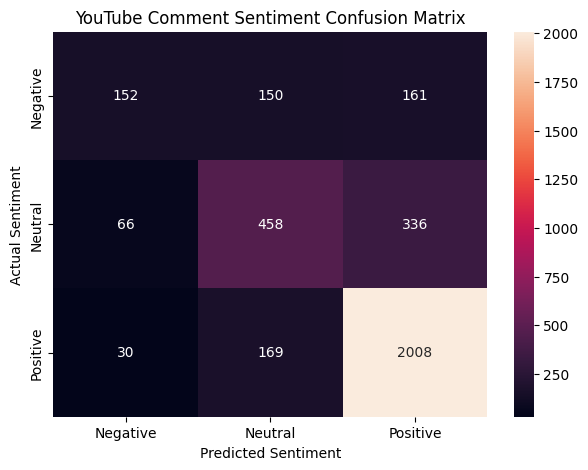

In [ ]:
labels = [
    'Negative',
    'Neutral',
    'Positive'
]

cm = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "YouTube Comment Sentiment Confusion Matrix"
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

**Model Performance**

**Description:** This graph compares the main evaluation metrics of the Logistic Regression model.

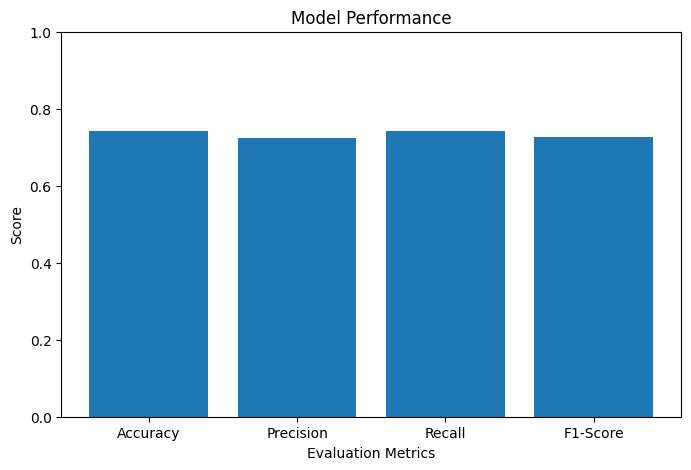

In [ ]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.ylim(0, 1)

plt.title("Model Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

plt.show()

**Create Sentiment Prediction Function**

**Description:**
This function accepts a new YouTube comment, preprocesses it, converts it into TF-IDF features, and predicts its sentiment.

In [ ]:
def predict_sentiment(comment):

    # Preprocess comment
    cleaned_comment = preprocess_text(
        comment
    )

    # Convert to TF-IDF
    comment_tfidf = tfidf.transform(
        [cleaned_comment]
    )

    # Predict sentiment
    prediction = model.predict(
        comment_tfidf
    )[0]

    print("Original Comment:")
    print(comment)

    print("\nPredicted Sentiment:")
    print(prediction)

**Test Positive Comment**

**Description:**
A positive YouTube comment is tested using the trained model.

In [ ]:
predict_sentiment(
    "This video is amazing and very helpful!"
)

Original Comment:
This video is amazing and very helpful!

Predicted Sentiment:
Positive


**Test Negative Comment**

**Description:**
A negative YouTube comment is tested using the trained model.

In [ ]:
predict_sentiment(
    "This video is terrible and completely useless."
)

Original Comment:
This video is terrible and completely useless.

Predicted Sentiment:
Negative


**Test Neutral Comment**

**Description:**
A neutral YouTube comment is tested using the trained model.

In [ ]:
predict_sentiment(
    "The video explains the topic clearly."
)

Original Comment:
The video explains the topic clearly.

Predicted Sentiment:
Neutral


**Interactive Sentiment Prediction**

**Description:**
This section allows the user to enter any YouTube comment and obtain the predicted sentiment.

In [ ]:
user_comment = input(
    "Enter a YouTube comment: "
)

predict_sentiment(user_comment)

Enter a YouTube comment: here in nz 50 of retailers don’t even have con...
Original Comment:
here in nz 50 of retailers don’t even have con...

Predicted Sentiment:
Negative


**Final Dataset Details**

**Description:**
This section displays the actual number of records, fields, target variable, sentiment classes, and class distribution.

In [ ]:
print("DATASET DETAILS")
print("============================")

print("Dataset Size:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDataset Fields:")
print(df.columns.tolist())

print("\nTarget Variable:")
print("sentiment")

print("\nSentiment Classes:")
print(df['sentiment'].unique())

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

DATASET DETAILS
Dataset Size:
Rows: 18139
Columns: 3

Dataset Fields:
['comment', 'sentiment', 'cleaned_comment']

Target Variable:
sentiment

Sentiment Classes:
['Neutral' 'Negative' 'Positive']

Class Distribution:
sentiment
Positive    11382
Neutral      4422
Negative     2335
Name: count, dtype: int64


**Results**

**Description:**
The results section summarizes the performance of the sentiment classification model.

In [ ]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.752205
1,Precision,0.737477
2,Recall,0.752205
3,F1-Score,0.735757


## Conclusion

This project developed an NLP-based sentiment analysis system
for YouTube comments.

The comments were cleaned and preprocessed using NLP techniques.
TF-IDF was used to convert text into numerical features.
Logistic Regression was used to classify comments into
Positive, Neutral, and Negative sentiments.

The model was evaluated using Accuracy, Precision, Recall,
F1-Score, and Confusion Matrix.

The project demonstrates how Natural Language Processing
and Machine Learning can be used to automatically analyse
opinions expressed in YouTube comments.